Rice 8a: Number of rice grains detected = 20


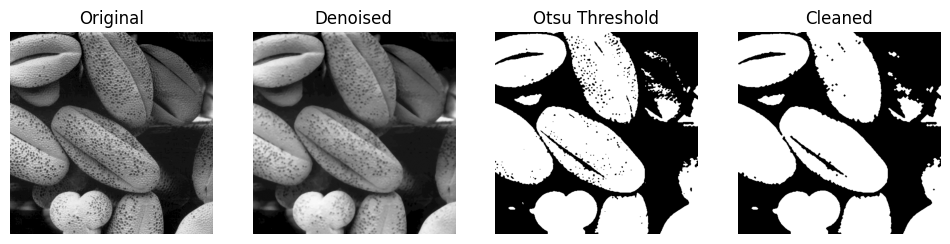

Rice 8a: Number of rice grains detected = 1


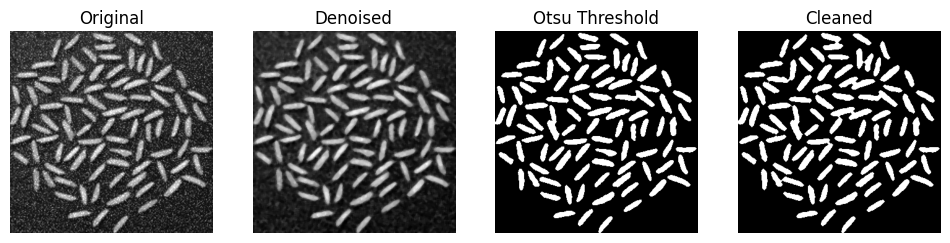

Rice 8b: Number of rice grains detected = 1


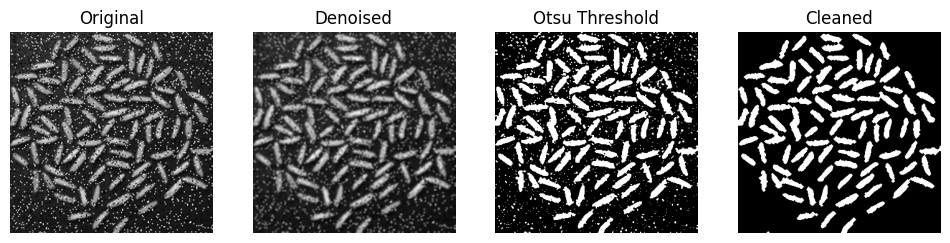

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(img, method='median'):
    """Denoise the image using specified method"""
    if method == 'median':
        return cv2.medianBlur(img, 5)
    elif method == 'gaussian':
        return cv2.GaussianBlur(img, (5,5), 0)
    else:
        raise ValueError("Unknown method: choose 'median' or 'gaussian'")

def otsu_segmentation(img):
    """Apply Otsu's thresholding"""
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return thresh

def morphological_clean(thresh):
    """Remove small objects and fill holes"""
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel, iterations=2)
    return cleaned

def count_rice_grains(cleaned_img):
    """Count rice grains using connected components"""
    binary = cv2.bitwise_not(cleaned_img)
    num_labels, labels_im = cv2.connectedComponents(binary)
    return num_labels - 1, labels_im

def process_rice_image(filename, method='median', title='Rice Image'):

    img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

    denoised = preprocess_image(img, method)


    thresh = otsu_segmentation(denoised)


    cleaned = morphological_clean(thresh)

    count, labels_im = count_rice_grains(cleaned)

    print(f"{title}: Number of rice grains detected = {count}")

    plt.figure(figsize=(12,5))
    plt.subplot(1,4,1); plt.title("Original"); plt.imshow(img, cmap='gray'); plt.axis('off')
    plt.subplot(1,4,2); plt.title("Denoised"); plt.imshow(denoised, cmap='gray'); plt.axis('off')
    plt.subplot(1,4,3); plt.title("Otsu Threshold"); plt.imshow(thresh, cmap='gray'); plt.axis('off')
    plt.subplot(1,4,4); plt.title("Cleaned"); plt.imshow(cleaned, cmap='gray'); plt.axis('off')
    plt.show()

    return cleaned, labels_im
cleaned_a, labels_a = process_rice_image('/content/sample_data/shells.tif', method='median', title='Rice 8a')


cleaned_a, labels_a = process_rice_image('/content/sample_data/rice_a.png', method='median', title='Rice 8a')


cleaned_b, labels_b = process_rice_image('/content/sample_data/rice_b.png', method='gaussian', title='Rice 8b')
